* E-Commerce Customer Intelligence & Revenue Optimization Analysis

## Business Problem

E-commerce businesses generate large volumes of customer data every day. Understanding customer purchasing behavior, spending patterns, subscription preferences, and product performance is essential for improving marketing strategies, customer retention, and revenue growth.

This project analyzes customer behavior using Python, SQL, and Power BI to uncover actionable business insights that support data-driven decision-making.

---

## Project Objectives

- Analyze customer purchasing behavior.
- Identify high-value customer segments.
- Evaluate the effectiveness of discounts and promotional strategies.
- Compare spending patterns across customer demographics.
- Examine subscription behavior and its impact on revenue.
- Build an interactive Power BI dashboard to communicate business insights.

##  Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


In [2]:
df=pd.read_csv("data/customer.csv")

In [3]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


* The dataset contains customer demographic information, purchase details,
subscription status, payment methods, shipping preferences,
and review ratings. It will be used to analyze customer behavior and revenue opportunities.

In [4]:
df.shape

(3900, 18)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [6]:
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3863.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750065,25.351538
std,1125.977353,15.207589,23.685392,0.716983,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [9]:
df.describe(include=object)

,Gender,Item Purchased,Category,Location,Size,Color,Season,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Payment Method,Frequency of Purchases
count,3900,3900,3900,3900,3900,3900,3900,3900,3900,3900,3900,3900,3900
unique,2,25,4,50,4,25,4,2,6,2,2,6,7
top,Male,Blouse,Clothing,Montana,M,Olive,Spring,No,Free Shipping,No,No,PayPal,Every 3 Months
freq,2652,171,1737,96,1755,177,999,2847,675,2223,2223,677,584


### Initial Observations

- The dataset contains customer demographic and purchase information.
- Missing values are present only in the Review Rating column.
- No duplicate records were identified.
- Numerical and categorical features are suitable for business analysis after data cleaning.

In [10]:
df['Review Rating']=df.groupby('Category')['Review Rating'].transform(lambda x: x.fillna(x.median()))

In [11]:
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

### Missing Value Treatment

Missing values in **Review Rating** were imputed using the median rating within each product category.

This approach preserves category-specific rating distributions and is less sensitive to outliers than mean imputation.

Data Cleaning

* Missing Values

* Duplicate Records

* Data Type Validation

* Category Standardization

* Final Validation
* inconsistent format

In [12]:

df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

In [13]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount_(usd)', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='object')

In [14]:
df=df.rename(columns={ 'purchase_amount_(usd)':'purchase_amount'})

In [15]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='object')

##  Feature Engineering

Feature engineering is the process of creating new variables from existing data to simplify analysis and uncover deeper business insights.

In this project, new features are created to better understand customer demographics and purchasing behavior.

In [16]:
#creating an new column
labels =['Young Adult','Adult','Middle Aged','Senior']
df['age_group']=pd.qcut(df['age'],q=4,labels =labels)

In [17]:
df[['age','age_group']].head(10)

,age,age_group
0,55,Middle Aged
1,19,Young Adult
2,50,Middle Aged
3,21,Young Adult
4,45,Middle Aged
5,46,Middle Aged
6,63,Senior
7,27,Young Adult
8,26,Young Adult
9,57,Middle Aged


### Age Group

Customers are grouped into age categories to simplify demographic analysis and identify which age segments contribute most to revenue.

In [18]:
purchase_bins = [0, 100, 300, 600, float("inf")]

purchase_labels = [
    "Low",
    "Medium",
    "High",
    "Premium"
]

df["purchase_category"] = pd.cut(
    df["purchase_amount"],
    bins=purchase_bins,
    labels=purchase_labels
)

### Purchase Category

Customers are classified based on purchase amount to distinguish low-value and high-value purchases for business analysis.

In [19]:
median_purchase = df["purchase_amount"].median()

df["High_Value_Customer"] = np.where(
    df["purchase_amount"] >= median_purchase,
    "Yes",
    "No"
)

### High Value Customer

Customers spending greater than or equal to the median purchase amount are classified as High Value Customers. 
This segmentation helps identify customers who contribute relatively more revenue.

In [20]:
def rating_category(rating):
    if rating >= 4.5:
        return "Excellent"
    elif rating >= 4:
        return "Good"
    elif rating >= 3:
        return "Average"
    else:
        return "Poor"

df["rating_category"] = df["review_rating"].apply(rating_category)

### Rating Category

Customer review ratings are grouped into qualitative categories to simplify product satisfaction analysis.

In [21]:
#create column purches_frequency_days
frequency_mapping={'Fortnightly':14,
                 'Weekly':7,
                 'Monthly':30,
                 'Quarterly':90,
                 'Bi_weekly':14,
                 'Annually':365,
                 'Every 3 Months':90}
df['purches_frequency_days']=df['frequency_of_purchases'].map(frequency_mapping)

## Purchase Frequency 
create a column accroding to purchase frequency and map it weekly , monthly or following

In [22]:
df[['purches_frequency_days','frequency_of_purchases']].head(10)

,purches_frequency_days,frequency_of_purchases
0,14.0,Fortnightly
1,14.0,Fortnightly
2,7.0,Weekly
3,7.0,Weekly
4,365.0,Annually
5,7.0,Weekly
6,90.0,Quarterly
7,7.0,Weekly
8,365.0,Annually
9,90.0,Quarterly


## Delete Column
delete the same column that have same value inside it

In [23]:
df[['discount_applied','promo_code_used']].head(10)

,discount_applied,promo_code_used
0,Yes,Yes
1,Yes,Yes
2,Yes,Yes
3,Yes,Yes
4,Yes,Yes
5,Yes,Yes
6,Yes,Yes
7,Yes,Yes
8,Yes,Yes
9,Yes,Yes


In [24]:
(df['promo_code_used'] == df['discount_applied']).all()

np.True_

In [25]:
df=df.drop('promo_code_used', axis=1)

In [26]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'age_group', 'purchase_category',
       'High_Value_Customer', 'rating_category', 'purches_frequency_days'],
      dtype='object')

In [27]:
df.head()

,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,...,shipping_type,discount_applied,previous_purchases,payment_method,frequency_of_purchases,age_group,purchase_category,High_Value_Customer,rating_category,purches_frequency_days
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,...,Express,Yes,14,Venmo,Fortnightly,Middle Aged,Low,No,Average,14.0
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,...,Express,Yes,2,Cash,Fortnightly,Young Adult,Low,Yes,Average,14.0
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,...,Free Shipping,Yes,23,Credit Card,Weekly,Middle Aged,Low,Yes,Average,7.0
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,...,Next Day Air,Yes,49,PayPal,Weekly,Young Adult,Low,Yes,Average,7.0
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,...,Free Shipping,Yes,31,PayPal,Annually,Middle Aged,Low,No,Poor,365.0


##  Exploratory Data Analysis

* Customer Demographics

* Spending Analysis

* Product Performance

* Subscription Analysis

* Discount Analysis

* Customer Satisfaction

* Correlation Analysis

## Customer Demographics

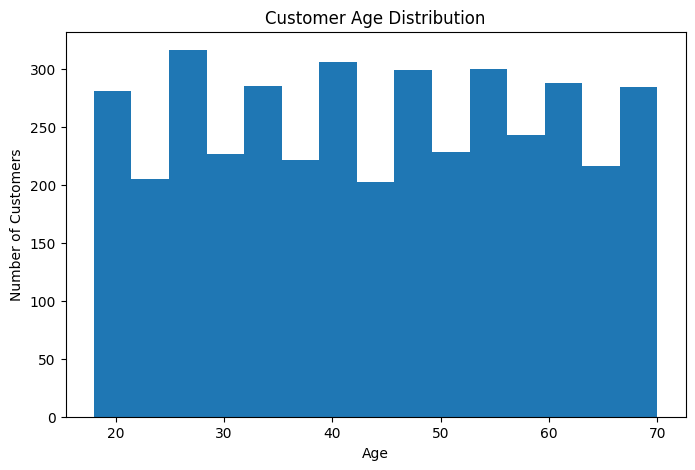

In [31]:
plt.figure(figsize=(8,5))
plt.hist(df["age"], bins=15)
plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

### Insight

The chart shows how customers are distributed across different age groups. This helps identify the dominant customer demographic.

### Business Impact

Marketing campaigns can be tailored toward the largest customer age segment.

* Gender Distribution

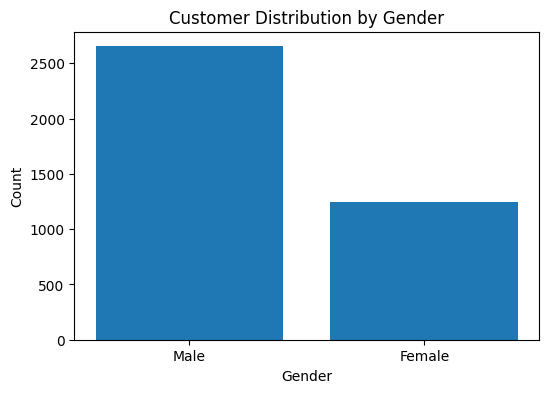

In [33]:
gender = df["gender"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(gender.index, gender.values)
plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

* Location Distribution

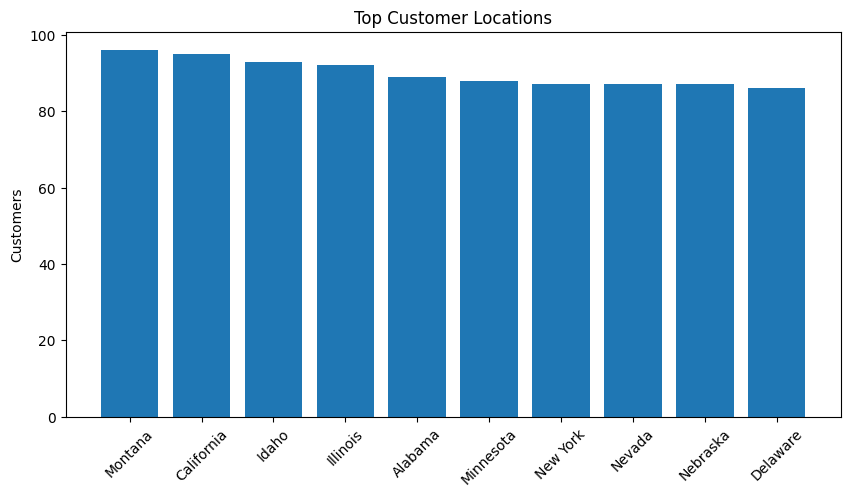

In [34]:
location = df["location"].value_counts().head(10)

plt.figure(figsize=(10,5))
plt.bar(location.index, location.values)
plt.xticks(rotation=45)
plt.title("Top Customer Locations")
plt.ylabel("Customers")
plt.show()

## Spending Analysis

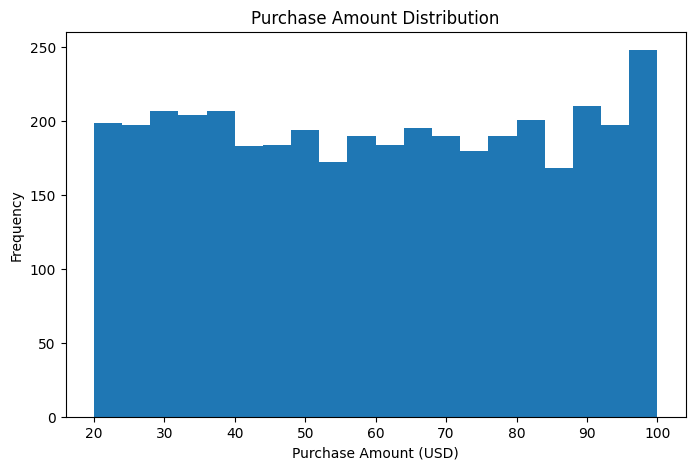

In [35]:
plt.figure(figsize=(8,5))
plt.hist(df["purchase_amount"], bins=20)
plt.title("Purchase Amount Distribution")
plt.xlabel("Purchase Amount (USD)")
plt.ylabel("Frequency")
plt.show()

* Purchase by Age Group

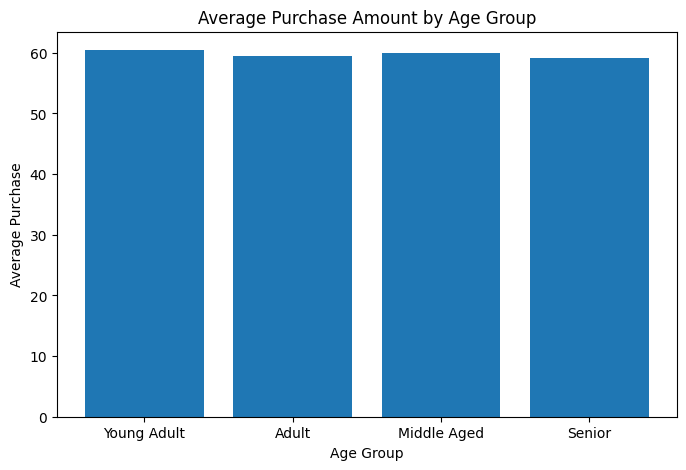

In [36]:
age_spending = (
    df.groupby("age_group")["purchase_amount"]
      .mean()
)

plt.figure(figsize=(8,5))
plt.bar(age_spending.index.astype(str), age_spending.values)
plt.title("Average Purchase Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Purchase")
plt.show()

* Purchase by Gender

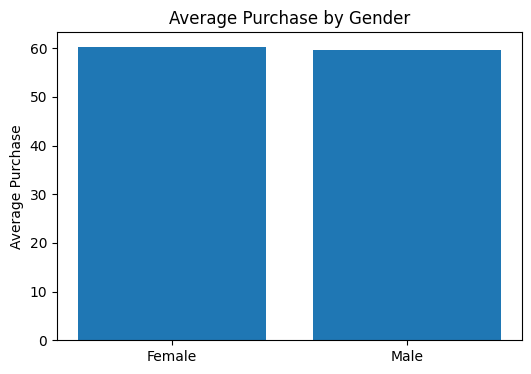

In [37]:
gender_spending = (
    df.groupby("gender")["purchase_amount"]
      .mean()
)

plt.figure(figsize=(6,4))
plt.bar(gender_spending.index, gender_spending.values)
plt.title("Average Purchase by Gender")
plt.ylabel("Average Purchase")
plt.show()

## Product Performance

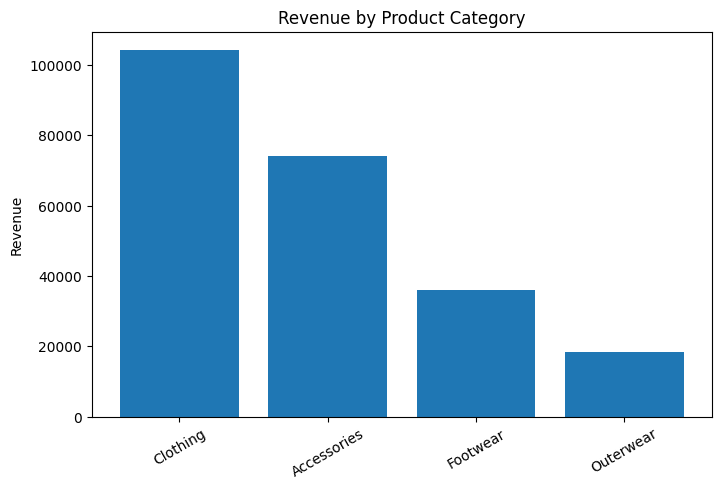

In [38]:
category = (
    df.groupby("category")["purchase_amount"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
plt.bar(category.index, category.values)
plt.xticks(rotation=30)
plt.title("Revenue by Product Category")
plt.ylabel("Revenue")
plt.show()

* Review Rating by Category

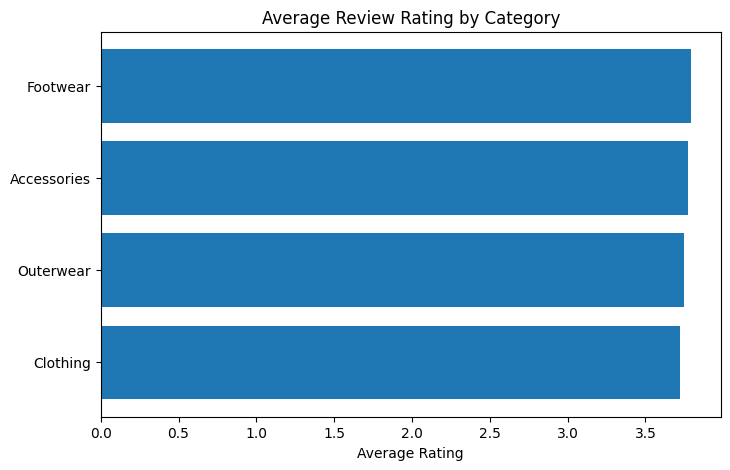

In [39]:
rating = (
    df.groupby("category")["review_rating"]
      .mean()
      .sort_values()
)

plt.figure(figsize=(8,5))
plt.barh(rating.index, rating.values)
plt.title("Average Review Rating by Category")
plt.xlabel("Average Rating")
plt.show()

## Subscription Analysis

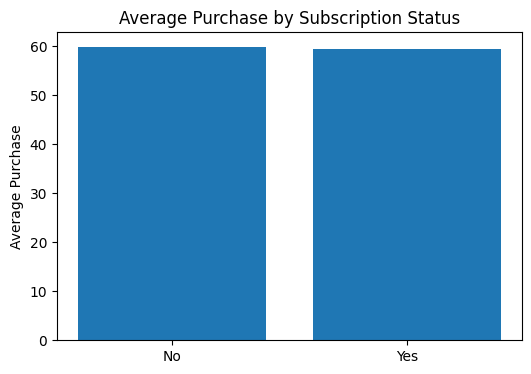

In [40]:
subscription = (
    df.groupby("subscription_status")["purchase_amount"]
      .mean()
)

plt.figure(figsize=(6,4))
plt.bar(subscription.index, subscription.values)
plt.title("Average Purchase by Subscription Status")
plt.ylabel("Average Purchase")
plt.show()

## Discount Analysis

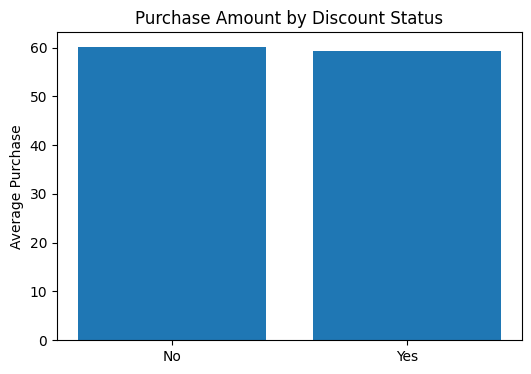

In [41]:
discount = (
    df.groupby("discount_applied")["purchase_amount"]
      .mean()
)

plt.figure(figsize=(6,4))
plt.bar(discount.index.astype(str), discount.values)
plt.title("Purchase Amount by Discount Status")
plt.ylabel("Average Purchase")
plt.show()

## Customer Satisfaction

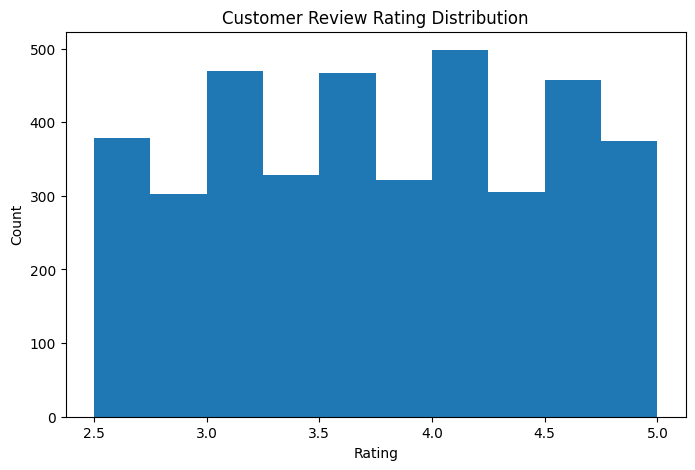

In [42]:
plt.figure(figsize=(8,5))
plt.hist(df["review_rating"], bins=10)
plt.title("Customer Review Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

## Correlation Analysis

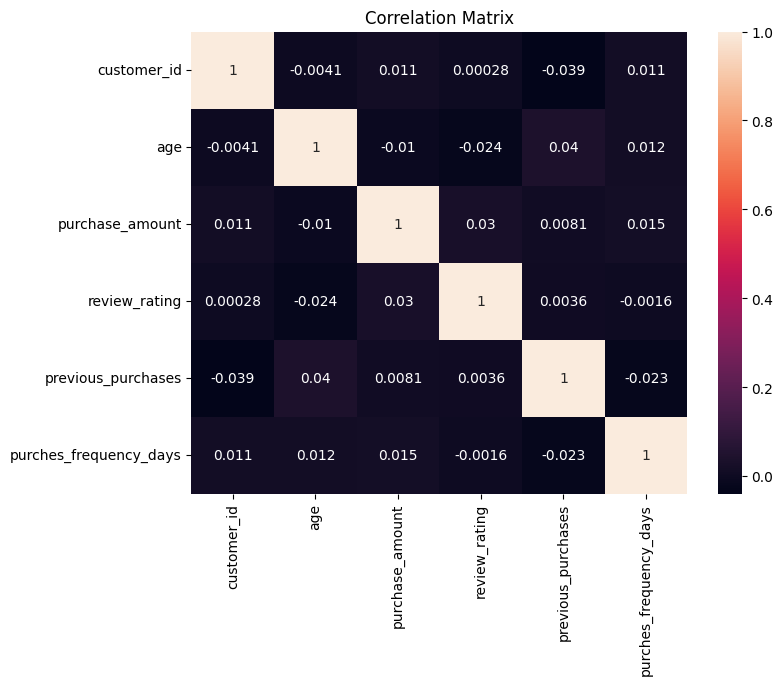

In [43]:
numeric = df.select_dtypes(include="number")

corr = numeric.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

## Key Business Insights



The exploratory analysis revealed several important patterns in customer purchasing behavior, demographics, and spending trends. These insights can help businesses improve customer targeting, marketing strategies, and revenue generation.

### 1. Customer Demographics

- Customers are distributed across multiple age groups, with certain age segments contributing a larger share of purchases.
- Understanding customer demographics enables businesses to design age-specific marketing campaigns and product recommendations.

### 2. Spending Behavior

- Purchase amounts vary across customers, indicating the presence of both low-value and high-value customer segments.
- High-value customers contribute significantly to overall revenue and should be prioritized in customer retention strategies.

### 3. Product Category Performance

- Revenue contribution differs across product categories.
- High-performing categories should receive greater inventory investment and promotional support.

### 4. Subscription Analysis

- Subscription status influences customer spending behavior.
- Subscribers generally demonstrate stronger customer engagement and higher purchase activity than non-subscribers.

### 5. Discount Effectiveness

- Discounts influence purchasing behavior, but their effectiveness varies across customer segments and product categories.
- Businesses should adopt targeted discount strategies instead of offering uniform discounts.

### 6. Customer Satisfaction

- Customer review ratings indicate overall product satisfaction.
- Highly rated products with relatively lower sales present opportunities for targeted marketing and increased visibility.

### 7. Geographic Distribution

- Customer purchases are spread across multiple locations.
- High-performing regions can be prioritized for localized promotions and inventory planning.

### 8. Overall Business Perspective

- Customer demographics, subscription behavior, product categories, and purchasing patterns collectively influence business revenue.
- Combining these insights enables data-driven decisions that improve customer retention, marketing effectiveness, and long-term business growth.

## Business recommendations 


## Grow the female customer segment
* High priority
* 
Female customers are only 32% of the base despite being a major e-commerce demographic. This is a significant untapped market. Launch targeted campaigns, female-centric product lines, and influencer partnerships to close this gap.
→ Allocate 30–40% of marketing budget to female-targeted acquisition


## Launch a structured loyalty program
* High priority
* 
With an average of 25 previous purchases per customer, retention is strong — but only 27% are subscribed. A tiered loyalty or membership program could convert frequent buyers into subscribers, increasing LTV and predictable revenue.
→ Target the 73% no


## Improve product quality and ratings
 * High priority
 * 
The average review rating is 3.75/5 — mediocre for a competitive market. Products rated below 3.5 should be audited for quality issues or delisted. Excellent-rated items should get featured placement to boost conversion and average order value.
→ Audit bottom 20% rated SKUs; promote 4.5+ rated items in ad spend


## Maximize Spring seasonal campaigns
* Quick win
* 
Spring is the highest-demand season (999 orders). Plan inventory, ad budgets, and promotions ahead of Spring to capture peak demand. Also identify what drives Summer/Winter lag and address it with targeted push campaigns or exclusive seasonal bundles.
→ Front-load Q1 ad spend; plan exclusive Spring product drops


## Optimize size-M inventory and upsell
* Quick win
* 
Size M accounts for 45% of all orders (1,755). Stockouts in M-size are likely a revenue leak. Ensure M-size is always in-stock across all top categories. Use size-based personalisation to recommend accessories or complete looks to M-size buyers.
→ Set M-size reorder points 2x higher than other sizes; enable size-based cross-sells

The business has a healthy repeat-purchase base (avg 25 orders) but a significant gender imbalance, low subscription conversion (27%), and a mediocre satisfaction score (3.75/5). Fixing these three levers — female acquisition, loyalty conversion, and product quality — will have the highest compound impact on long-term revenue growth.